In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
boston = fetch_openml(name='boston', version=1, as_frame=True)

In [4]:
df = boston.frame

print("First 5 Rows:\n")
print(df.head())

First 5 Rows:

      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [5]:
print("\nShape of Dataset:")
print(df.shape)


Shape of Dataset:
(506, 14)


In [6]:
print("\nColumns:\n")
print(df.columns)


Columns:

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='str')


In [13]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']
# Convert all columns to numeric
X = X.apply(pd.to_numeric)
# Convert target also
y = pd.to_numeric(y)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = LinearRegression()

In [16]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
y_pred = model.predict(X_test)

In [18]:
print("\nMean Squared Error:")
print(mean_squared_error(y_test, y_pred))


Mean Squared Error:
24.29111947497374


In [19]:
print("\nR2 Score:")
print(r2_score(y_test, y_pred))


R2 Score:
0.6687594935356289


In [20]:
print("\nIntercept:")
print(model.intercept_)


Intercept:
30.24675099392388


In [21]:
print("\nCoefficients:")
coef = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coef)


Coefficients:
         Coefficient
CRIM       -0.113056
ZN          0.030110
INDUS       0.040381
CHAS        2.784438
NOX       -17.202633
RM          4.438835
AGE        -0.006296
DIS        -1.447865
RAD         0.262430
TAX        -0.010647
PTRATIO    -0.915456
B           0.012351
LSTAT      -0.508571


In [22]:
result = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

In [23]:
print("\nActual vs Predicted:\n")
print(result.head(10))


Actual vs Predicted:

     Actual Price  Predicted Price
173          23.6        28.996724
274          32.4        36.025565
491          13.6        14.816944
72           22.8        25.031979
452          16.1        18.769880
76           20.0        23.254429
316          17.8        17.662538
140          14.0        14.341190
471          19.6        23.013207
500          16.8        20.632456


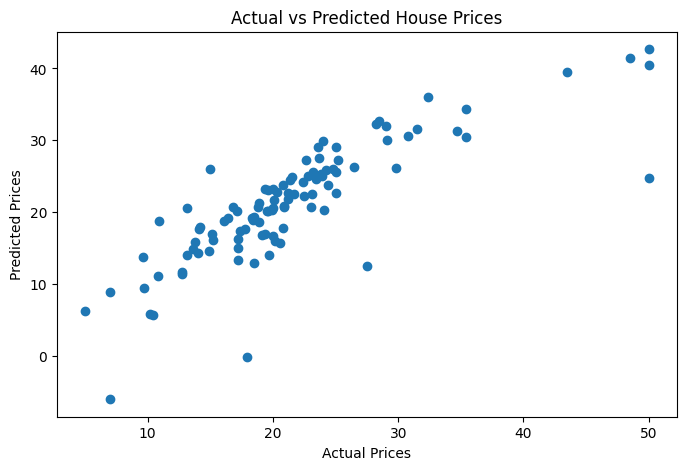

In [24]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

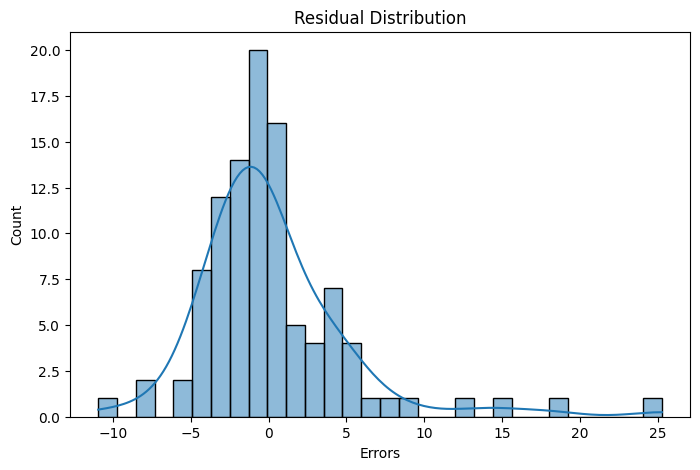

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(y_test - y_pred, bins=30, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Errors")
plt.show()